In [1]:
import requests
import re
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from scipy.optimize import curve_fit

In [2]:
books = [
    "https://www.gutenberg.org/files/1342/1342-0.txt",   
    "https://www.gutenberg.org/files/11/11-0.txt",       
    "https://www.gutenberg.org/files/84/84-0.txt",       
    "https://www.gutenberg.org/files/2701/2701-0.txt",   
    "https://www.gutenberg.org/files/1661/1661-0.txt",   
    "https://www.gutenberg.org/files/98/98-0.txt",       
    "https://www.gutenberg.org/files/74/74-0.txt",       
    "https://www.gutenberg.org/files/76/76-0.txt",       
    "https://www.gutenberg.org/files/1400/1400-0.txt",   
    "https://www.gutenberg.org/files/1232/1232-0.txt",   
    "https://www.gutenberg.org/files/5200/5200-0.txt",   
    "https://www.gutenberg.org/files/345/345-0.txt",     
    "https://www.gutenberg.org/files/2554/2554-0.txt",   
    "https://www.gutenberg.org/files/2600/2600-0.txt",   
    "https://www.gutenberg.org/files/1952/1952-0.txt"    
]

In [3]:
def clean_gutenberg_text(text):
    start = re.search(r"\*\*\* START OF.*?\*\*\*", text, re.IGNORECASE)
    end = re.search(r"\*\*\* END OF.*?\*\*\*", text, re.IGNORECASE)

    if start and end:
        text = text[start.end():end.start()]

    return text

def tokenize(text):
    text = text.lower()
    return re.findall(r"\b[a-z]+\b", text)

def download_and_tokenize(url):
    response = requests.get(url)
    text = response.text
    text = clean_gutenberg_text(text)
    tokenized = tokenize(text)
    return tokenized

Funkcja clean_gutenberg_text służy do znalenizienia startu i końca całej książki, która zwraca tekst między tymi elementami. 
Funkcja tokenize zamienia cały teksrt na małe litery a następnie znajduje wszystkie tokeny (słowa) za pomocą regexu(1 lub więcej tylko litery).
Funkcja download_and_tokenize pobiera tekst z internetu i wywołuje powyższe funkcje.

In [5]:
def heaps_law(n, k, b):

    return k * (n ** b)

def analyze_heaps(tokens):
    number_of_tokens = []  #liczba słów
    vocab_sizes = []       #liczba różnych słów
    vocab = set()          #zbiór uniklanych słów

    step = max(1000, len(tokens) // 100) #podział an kroki

    for i in range(step, len(tokens) + 1, step):
        vocab.update(tokens[:i])
        number_of_tokens.append(i)
        vocab_sizes.append(len(vocab))

    number_of_tokens = np.array(number_of_tokens)
    vocab_sizes = np.array(vocab_sizes)

    params, _ = curve_fit(heaps_law, number_of_tokens, vocab_sizes)
    k, b = params

    return number_of_tokens, vocab_sizes, k, b

Funkcja służy do analizy poszczególnych fragmentów tekstu, dodaje do zbioru słów wszystkie nowe słowa, dodaje liczbe słów oraz liczbę uniklanych słów. 
Następnie używam np i curve_fit aby wyznaczyć parametry przy pmocy metody najmniejszych kwadratów.

In [7]:
def plot_heaps(number_of_tokens, vocab_sizes, k, b, title):
    plt.figure(figsize=(10, 6))
    plt.scatter(number_of_tokens, vocab_sizes, s=15, label="Dane rzeczywiste")
    plt.plot(
        number_of_tokens,
        heaps_law(number_of_tokens, k, b),
        label=f"Model Heapsa: k={k:.2f}, b={b:.2f}"
    )
    plt.xlabel("Liczba tokenów")
    plt.ylabel("Liczba różnych słów")
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()

In [8]:
def zipf_law(rank, c):
    return c / rank


def analyze_zipf(tokens):
    freq = Counter(tokens)

    freqs = np.array(sorted(freq.values(), reverse=True))
    ranks = np.arange(1, len(freqs) + 1)

    c = freqs[0]

    return ranks, freqs, c

Fukcja służy do ustalenia liczby wystąpień każdego słowa, sortuje je od najczęstrzego i przypisuje im odpowiednie rangi.

In [10]:
def plot_zipf(ranks, freqs, c, title):
    plt.figure(figsize=(10, 6))
    plt.loglog(ranks, freqs, label="Dane rzeczywiste")
    plt.loglog(ranks, zipf_law(ranks, c), label=f"Model Zipfa: c={c:.2f}")
    plt.xlabel("Ranga")
    plt.ylabel("Częstotliwość")
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()

In [11]:
all_tokens = []


for i, url in enumerate(books, 1):
    print(i,"/15")
    tokens = download_and_tokenize(url)
    all_tokens.extend(tokens) #łączenie wszystkich książek razem

print("Łączna liczba tokenów:")
l_all_tokens=len(all_tokens)
print(l_all_tokens)
print("Liczba różnych słów:")
l_s_all_tokens=len(set(all_tokens))
print(l_s_all_tokens)

1 /15
2 /15
3 /15
4 /15
5 /15
6 /15
7 /15
8 /15
9 /15
10 /15
11 /15
12 /15
13 /15
14 /15
15 /15
Łączna liczba tokenów:
2087628
Liczba różnych słów:
35504


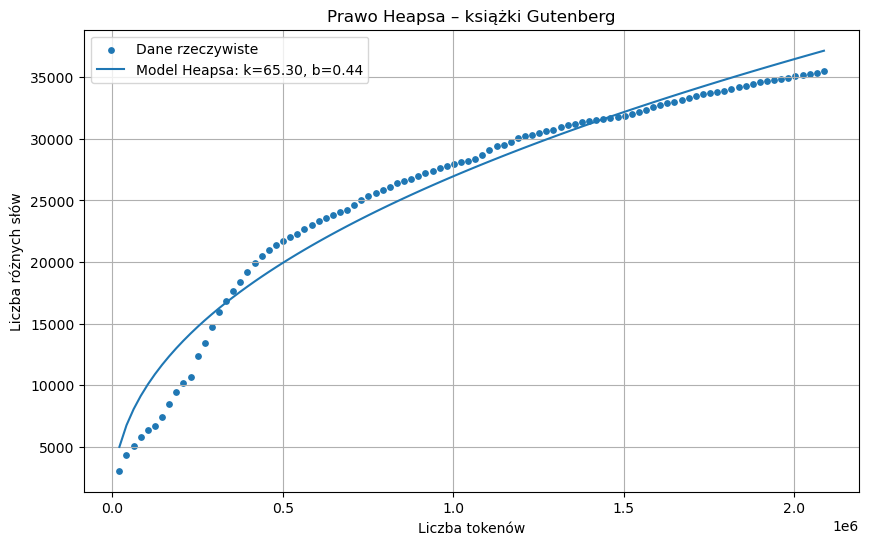

In [12]:
number_of_tokens, vocab_sizes, k, b = analyze_heaps(all_tokens)

plot_heaps(
    number_of_tokens,
    vocab_sizes,
    k,
    b,
    "Prawo Heapsa – książki Gutenberg"
)

Wartość b wynosi tutaj 0.44 co zgadza się z teoretyczną wartością dla języka angielskiego 0.4-0.6
Wartość K wynosi 65.30 więc mieści się w przedziale 10-100 i znajduje się w wyższej części co jest przewidywane dla tekstów literackich.

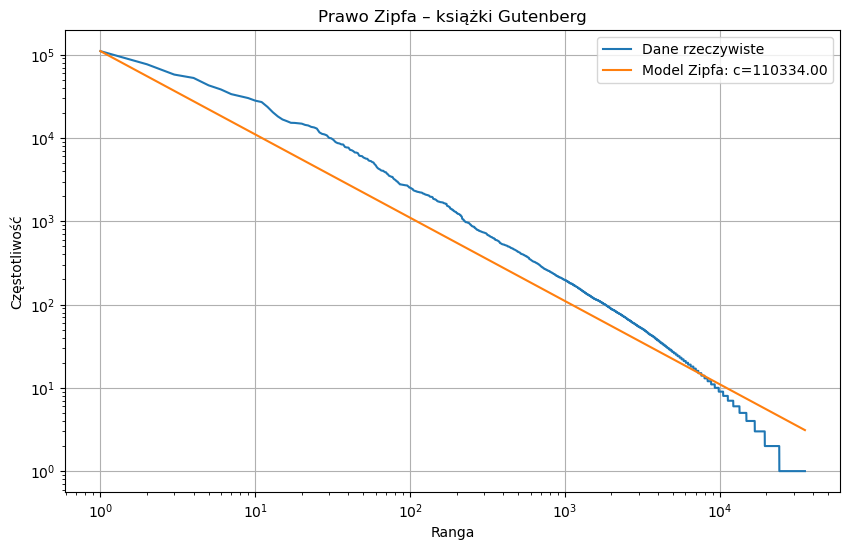

In [14]:
ranks, freqs, c = analyze_zipf(all_tokens)

plot_zipf(
    ranks,
    freqs,
    c,
    "Prawo Zipfa – książki Gutenberg"
)

Wykres w sklai logarytmicznej pokazuje zgodność tekstu z modelem teoretycznym. Dane rzeczywiste dla większości słów są dosyć blisko przybliżone prostą.

In [16]:
print("Generowanie losowego tekstu 10 mln znaków")

random_text = ''.join(random.choice('abcdef ') for _ in range(10000000))

random_tokens = random_text.split()

print("Liczba tokenów w tekście losowym:")
l_random_tokens=len(random_tokens)
print(l_random_tokens)
print("Liczba różnych słów:")
l_s_random_tokens=len(set(random_tokens))
print(l_s_random_tokens)

Generowanie losowego tekstu 10 mln znaków
Liczba tokenów w tekście losowym:
1225833
Liczba różnych słów:
524447


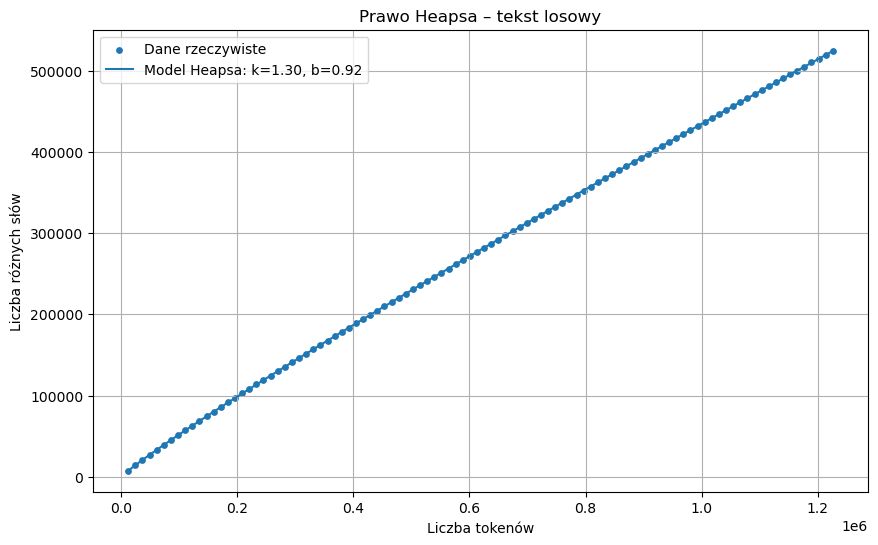

In [17]:
number_of_tokens_r, vocab_sizes_r, k_r, b_r = analyze_heaps(random_tokens)

plot_heaps(
    number_of_tokens_r,
    vocab_sizes_r,
    k_r,
    b_r,
    "Prawo Heapsa – tekst losowy"
)

Wartośc b wynosi 0.92 oraz k wynosi 1.3 co znaczy że większość słów w tym losowo generowanym tekście jest unikalna. 

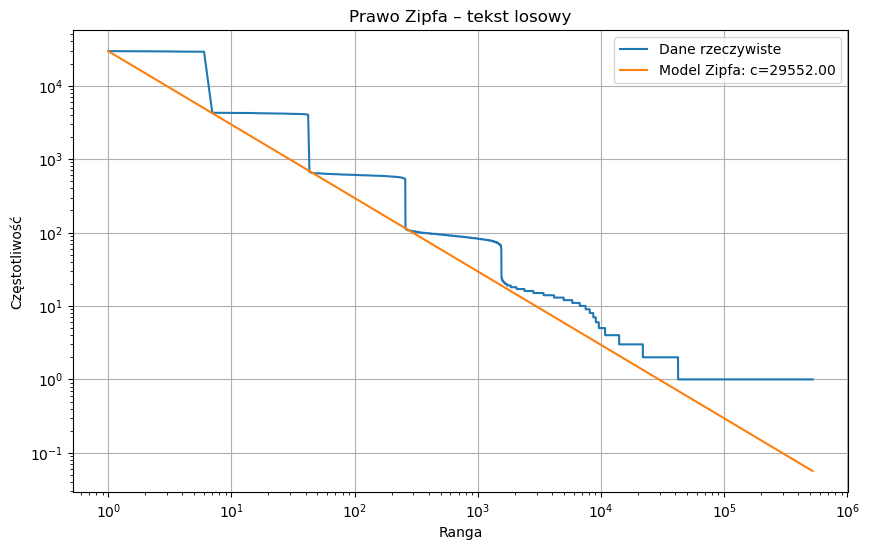

In [19]:
ranks_r, freqs_r, c_r = analyze_zipf(random_tokens)

plot_zipf(
    ranks_r,
    freqs_r,
    c_r,
    "Prawo Zipfa – tekst losowy"
)

Dane rzeczywiste są słabo przybliżone linią prostą. Skoki są spowodowane występowaniem duży liczby słów w takiej samej liczbie. 